In [62]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import torch

from xgboost import XGBClassifier
from pandas.api.types import CategoricalDtype

from sklearn.metrics import confusion_matrix, roc_curve
from sklearn.metrics import average_precision_score, f1_score, precision_score, recall_score

! pip install fairlearn
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.metrics import false_positive_rate, false_negative_rate, selection_rate

from fairlearn.metrics import MetricFrame

from xgboost import XGBClassifier

In [63]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [64]:
os.chdir("/content/drive/MyDrive/3. Grad School/리스크 관리 경진대회")

#### 데이터, 모델 불러오기

In [ ]:
data = pd.read_pickle("DATA/Health_Insurance_final.pkl")

In [ ]:
target = 'is_churn'

x_cols = [
    # 기본
    'premium', 'seniority_policy', 'type_policy_dg', 'type_product', 'new_business',
    'log_cost_claims_year', 'distribution_channel',
    # 나이 관련
    'age',
    # 성별 관련
    'gender',
    # 지역 관련
    'IICIMUN_capped', 'IICIPROV', 'C_C', 'C_H_num', 'C_GI', 'C_IE_T',
]

der_cols = [
    'missing_geo_cxt',       # 지역 결측 신호
    'high_loss',                  # 보험사 손해율
    'relative_poverty',        # 지역 내 상대적 빈곤
    'kr_premium_shock',   # 가격 인상 압박(비율 단위)
    'kr_economic_stress',  # 소득 대비 체감 부담
    # 'kr_retention_years',    # 장기 유지 혜택
    'kr_early_laps',             #신계약 위험 구간
    # 'kr_direct_channel',     # 가입 채널 영향
    'kr_medical_desert'     # 인프라 취약성
]

print(f"사용 변수 개수(기본) : {len(x_cols)}")
print(f"사용 변수 개수(파생) : {len(der_cols)}")
x_cols += der_cols
print(f"최종 변수 개수 : {len(x_cols)}개")

device = "cuda" if torch.cuda.is_available() else "cpu"

사용 변수 개수(기본) : 15
사용 변수 개수(파생) : 7
최종 변수 개수 : 22개


In [ ]:
### Encoding
cat_cols = ['type_policy_dg', 'type_product', 'new_business', 'distribution_channel', 'gender', 'C_C', 'kr_early_laps']

In [ ]:
import joblib
# XGBoost
model_data = joblib.load("Model/xgb_package2.pkl")
model = model_data['model']
fixed_params = model_data['fixed_params']
del fixed_params['early_stopping_rounds'] # Fairlearn에서는 early stopping 끄기 (여러 개의 모델을 만들어서 가중평균하는 방식이므로..)
best_params = model_data['best_params']
threshold = model_data['threshold']

y_pred = joblib.load("Model/xgb_pred2.pkl")

In [ ]:
for col in data[x_cols].columns:
    if col in cat_cols:
        data[col] = data[col].astype(str).astype('category')
    else:
        data[col] = data[col].astype(np.float64)

train = data[data['period'].isin([2017, 2018])]
val = data[data['period'] == 2018]
test = data[data['period'] == 2019]

x_train = train[x_cols]
y_train = train[target]
x_val = val[x_cols]
y_val = val[target]
x_test = test[x_cols]
y_test = test[target]

In [ ]:
# 불균형 데이터 가중치 계산
spw = (y_train == 0).sum() / (y_train == 1).sum()
device = "cuda" if torch.cuda.is_available() else "cpu"

#### 결과 저장 형식

In [65]:
from sklearn.metrics import accuracy_score
from fairlearn.metrics import (
    MetricFrame, selection_rate, true_positive_rate, false_positive_rate,
    demographic_parity_difference, equalized_odds_difference
)

def fairness_report(y_true, y_pred, y_prob, sensitive_features, threshold_info):
    metrics = {
        "selection_rate": selection_rate,
        "true_positive_rate": true_positive_rate,
        "false_positive_rate": false_positive_rate,
        'false_negative_rate': false_negative_rate,
    }

    mf = MetricFrame(
        metrics = metrics,
        y_true = y_true,
        y_pred = y_pred,
        sensitive_features = sensitive_features
    )

    report_dict = {
        "model_performance": {
            "f1_score": float(f1_score(y_true, y_pred)),
            "pr_auc": float(average_precision_score(y_true, y_prob)),
            "precision": float(precision_score(y_true, y_pred)),
            "recall": float(recall_score(y_true, y_pred))
        },
        "threshold_strategy": threshold_info, # 예: "Common: 0.5" 또는 {"Group_A": 0.4, "Group_B": 0.6}
        "fairness_metrics_by_group": mf.by_group.to_dict(), # 그룹별 상세 지표
        "fairness_max_disparity": mf.difference(method = 'between_groups').to_dict() # 집단 간 최대 격차
    }
    return report_dict

In [66]:
import shap

def shap_summary(model, x_test):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(x_test)

    # 절댓값 평균
    importance = np.abs(shap_values).mean(0)

    # 방향성 포함
    feature_names = x_test.columns
    correlations = []

    for i, col in enumerate(feature_names):
        feature_data_for_corr = None
        if x_test[col].dtype.name == 'category':
            feature_data_for_corr = x_test[col].cat.codes.astype(float)
        elif pd.api.types.is_numeric_dtype(x_test[col]):
            feature_data_for_corr = x_test[col].astype(float)
        else:
            print(f"Warning: Column '{col}' has an unsupported data type for correlation calculation: {x_test[col].dtype}. Correlation set to NaN.")
            correlations.append(np.nan)
            continue

        if feature_data_for_corr is not None:
            if len(np.unique(feature_data_for_corr)) < 2 or len(np.unique(shap_values[:, i])) < 2:
                corr = np.nan
            else:
                corr = np.corrcoef(feature_data_for_corr, shap_values[:, i])[0, 1]
            correlations.append(corr)
        else:
            correlations.append(np.nan)

    shap_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importance,
        'correlation': correlations
    }).sort_values(by='importance', ascending=False)

    shap_dict = {}
    for _, row in shap_df.head(10).iterrows(): # 상위 10개 피처
        if pd.isna(row['correlation']):
            direction_info = "N/A (Correlation undefined)"
        else:
            direction = "Positive" if row['correlation'] > 0 else "Negative"
            direction_info = f"{direction} (Correlation: {row['correlation']:.2f})"

        shap_dict[row['feature']] = {
            "importance": round(float(row['importance']), 4),
            "influence": direction_info
        }

    return shap_dict

In [67]:
def shap_summary_mitigator(model, x_test, nsamples = 100):
    def predict_fn(x):
        if isinstance(x, np.ndarray):
            x_df = pd.DataFrame(x, columns=x_test.columns)
            for col in x_test.columns:
                x_df[col] = x_df[col].astype(x_test[col].dtype)
        else:
            x_df = x
        try:
            return model._pmf_predict(x_df)[:, 1]
        except Exception as e:
            print(f"Error in predict_fn: {e}")
            return np.zeros(len(x_df))

    x_test_numeric = x_test.copy()
    for col in x_test_numeric.columns:
        if x_test_numeric[col].dtype.name == "category":
            x_test_numeric[col] = x_test_numeric[col].cat.codes.astype(float)
        elif pd.api.types.is_numeric_dtype(x_test_numeric[col]):
            x_test_numeric[col] = x_test_numeric[col].astype(float)

    background = shap.kmeans(x_test_numeric, 10)
    explainer = shap.KernelExplainer(predict_fn, background)

    test_sample = shap.sample(x_test_numeric, nsamples)
    shap_values = explainer.shap_values(test_sample)

    importance = np.abs(shap_values).mean(0)
    feature_names = x_test.columns
    correlations = []

    for i, col in enumerate(feature_names):
        s_val = shap_values[:, i].astype(float)
        f_val = test_sample[col].values.astype(float)

        mask = ~np.isnan(f_val) & ~np.isnan(s_val)
        if mask.sum() > 1:
            corr = np.corrcoef(f_val[mask], s_val[mask])[0, 1]
        else:
            corr = 0.0
        correlations.append(corr)

    shap_df = pd.DataFrame({'feature': feature_names, 'importance': importance, 'correlation': correlations})
    shap_df = shap_df.sort_values(by='importance', ascending=False)

    shap_dict = {}
    for _, row in shap_df.head(10).iterrows():
        direction = "Positive" if row['correlation'] > 0.01 else "Negative" if row['correlation'] < -0.01 else "Neutral"
        shap_dict[row['feature']] = {
            "importance": round(float(row['importance']), 4),
            "influence": f"{direction} (Corr: {row['correlation']:.2f})"
        }
    return shap_dict

#### 민감변수 처리

In [68]:
def get_sens_features(var_name, sens_config, x_train = x_train, x_val = x_val, x_test = x_test):
    """특정 변수에 대해 민감변수 속성 생성"""

    if var_name == 'gender':
        train_sens = x_train[var_name]
        val_sens = x_val[var_name]
        test_sens = x_test[var_name]

    if var_name == 'age':
        bins, labels = sens_config[var_name]['bins'], sens_config[var_name]['labels']
        train_sens = pd.cut(x_train[var_name], bins = bins, labels = labels)
        val_sens = pd.cut(x_val[var_name], bins = bins, labels = labels)
        test_sens = pd.cut(x_test[var_name], bins = bins, labels = labels)

    if var_name.lower() in ['c_gi', 'c_ie_t']:
        bins, labels = sens_config[var_name]['bins'], sens_config[var_name]['labels']
        var_name = var_name.upper()
        train_sens = pd.cut(x_train[var_name], bins = bins, labels = labels)
        val_sens = pd.cut(x_val[var_name], bins = bins, labels = labels)
        test_sens = pd.cut(x_test[var_name], bins = bins, labels = labels)

    if var_name.lower() == 'gender':
        train_sens = x_train[var_name]
        val_sens = x_val[var_name]
        test_sens = x_test[var_name]

    if var_name.lower() == 'c_h':
        train_sens = x_train['C_H_num'].map(sens_config[var_name]['c_h_map_inv'])
        val_sens = x_val['C_H_num'].map(sens_config[var_name]['c_h_map_inv'])
        test_sens = x_test['C_H_num'].map(sens_config[var_name]['c_h_map_inv'])

    if var_name.lower() == 'age_gender':
        bins, labels = sens_config[var_name]['bins'], sens_config[var_name]['labels']
        age_train_bin = pd.cut(x_train['age'], bins = bins, labels = labels)
        age_val_bin = pd.cut(x_val['age'], bins = bins, labels = labels)
        age_test_bin = pd.cut(x_test['age'], bins = bins, labels = labels)
        train_sens = pd.DataFrame({'gen_age': x_train['gender'].astype(str) + "_" + age_train_bin.astype(str)})
        val_sens = pd.DataFrame({'gen_age': x_val['gender'].astype(str) + "_" + age_val_bin.astype(str)})
        test_sens = pd.DataFrame({'gen_age': x_test['gender'].astype(str) + "_" + age_test_bin.astype(str)})

    return train_sens, val_sens, test_sens

In [69]:
sens_config = {
    'age':{
        'bins' : [0, 19, 29, 39, 49, 59, 69, 100],
        'labels' : ['10s', '20s', '30s', '40s', '50s', '60s', '70s+']
    },
    'age_gender':{
        'bins' :  [0, 25, 40, 60, 100],
        'labels' : ['청년', '장년', '중년', '고령']
    },
    'c_gi':{
        'bins' : [-2, 0, 25, 50, 75, 100],
        'labels' : ['Unknown', 'GI_1', 'GI_2', 'GI_3', 'GI_4']
    },
    'c_ie_t':{
        'bins' : [-2, 0, 25, 50, 75, 100],
        'labels' :['Unknown', 'C_IE_T_1', 'C_IE_T_2', 'C_IE_T_3', 'C_IE_T_4']
    },
    'c_h':{
        'c_h_map_inv' : {500: 'H1', 5500: 'H2', 17500: 'H3', 37500: 'H4', 75000: 'H5', 150000: 'H6', -1: 'Unknown'}
    }
}

#### 기본 모델

In [70]:
def report_base_model(x_train, x_test, y_train, y_test, threshold, var_name, x_test_sensitive):
    final_params = {**best_params, **fixed_params}

    # 모델 학습
    model = XGBClassifier(**final_params, enable_categorical = True)
    model.fit(x_train, y_train, verbose = False)

    # 추론
    y_prob = model.predict_proba(x_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    report_dict = fairness_report(y_test, y_pred, y_prob, x_test_sensitive, threshold)
    return model, y_prob, report_dict

#### 모델링/임계값 함수

In [ ]:
def fairlearn_model(x_train, y_train, x_test, y_test,
                    x_train_sensitive, x_test_sensitive,
                    best_params, fixed_params,
                    epsilon = 0.05, n_iter = 30):

    # 제약 조건 설정
    eo_constraints = EqualizedOdds()

    # 베이스 모델 정의
    base_model = XGBClassifier(
        **best_params,
        **fixed_params,
        enable_categorical = True
    )

    # Mitigator 정의
    mitigator = ExponentiatedGradient(
        estimator = base_model,
        constraints = eo_constraints,
        eps = epsilon, # 공정성 허용 오차. 작을수록 더 강력하게 차별을 방지 but 정확도 희생
        max_iter = n_iter
    )

    # 재학습
    print("\n⚖️ Fairlearn 재학습 중...")
    mitigator.fit(x_train, y_train, sensitive_features = x_train_sensitive)

    # 예측
    y_pred_mit = mitigator.predict(x_test)
    y_prob_mit = mitigator._pmf_predict(x_test)[:, 1]

    threshold_info = {
        "strategy": "In-processing (Randomized Ensemble)",
        "description": "Exponentiated Gradient 방식은 단일 임계값이 아닌, 공정성 제약 조건을 만족하는 복수 모델의 확률적 가중치를 활용함",
        "epsilon_parameter": epsilon,
        "max_iter": n_iter
    }

    report_dict = fairness_report(y_test, y_pred_mit, y_prob_mit, x_test_sensitive, threshold_info)
    return mitigator, y_prob_mit, report_dict

In [72]:
def fairlearn_tune(mitigator, y_prob_mit, x_val, y_val, x_test, y_test, x_train_sensitive, x_val_sensitive, x_test_sensitive):
    thresholds, threshold_dict, y_pred_post = threshold_tuning(mitigator, x_val, y_val, x_test, y_test, x_val_sensitive, x_test_sensitive, y_prob_mit)
    report_dict = fairness_report(y_test, y_pred_post, y_prob_mit, x_test_sensitive, threshold_dict)

    return report_dict

def threshold_tuning(mitigator, x_val, y_val, x_test, y_test,
                     x_val_sensitive, x_test_sensitive, y_prob_mit):

    y_val_prob = mitigator._pmf_predict(x_val)[:, 1]
    y_val_pred = mitigator.predict(x_val)

    mf_val = MetricFrame(metrics = false_positive_rate, y_true = y_val, y_pred = y_val_pred, sensitive_features = x_val_sensitive)
    target_fpr = mf_val.by_group.mean()

    thresholds, threshold_dict = get_group_thresholds(y_test, y_prob_mit, x_test_sensitive, target_fpr)
    y_pred_post = apply_group_thresholds(y_prob_mit, x_test_sensitive, thresholds)

    # 튜닝 전 FPR 격차
    y_pred_orig = mitigator.predict(x_test)
    mf_before = MetricFrame(metrics={'fpr': false_positive_rate}, y_true=y_test, y_pred=y_pred_orig, sensitive_features=x_test_sensitive)
    fpr_gap_before = mf_before.difference(method='between_groups')['fpr']

    # 튜닝 후 FPR 격차
    mf_after = MetricFrame(metrics={'fpr': false_positive_rate}, y_true=y_test, y_pred=y_pred_post, sensitive_features=x_test_sensitive)
    fpr_gap_after = mf_after.difference(method='between_groups')['fpr']

    # 튜닝 후 더 나빠졌으면 원래 예측값 사용
    if fpr_gap_after > fpr_gap_before + 0.01:
        print(f"⚠️ 튜닝 후 FPR 격차가 더 벌어짐 ({fpr_gap_before:.4f} → {fpr_gap_after:.4f}), mitigator 원래 예측값으로 대체합니다.")
        y_pred_post = y_pred_orig

        # 경험적 임계값 추정
        x_test_sensitive_arr = np.array(x_test_sensitive).flatten()
        y_prob_arr = np.array(y_prob_mit).flatten()

        thresholds = {}
        for group in np.unique(x_test_sensitive_arr):
            mask = (x_test_sensitive_arr == group)
            group_probs = y_prob_arr[mask]
            group_preds = y_pred_post[mask]

            pos_samples = group_probs[group_preds == 1]
            neg_samples = group_probs[group_preds == 0]

            pos_min = pos_samples.min() if len(pos_samples) > 0 else 1.0
            neg_max = neg_samples.max() if len(neg_samples) > 0 else 0.0

            thresholds[group] = (pos_min + neg_max) / 2 if (pos_min and neg_max) else (pos_min or neg_max)

    return thresholds, threshold_dict, y_pred_post

def get_group_thresholds(y_true, y_prob, sensitive_features, target_fpr):
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    sensitive_features = np.array(sensitive_features).flatten()

    group_thresholds, group_status = {}, {}
    groups = np.unique(sensitive_features)

    plt.figure(figsize = (10, 6))

    for group in groups:
        mask = (sensitive_features == group)
        # 이미 0/1로 분류되었거나 한 쪽 클래스만 있는 경우
        if len(np.unique(y_prob[mask])) < 2:
            group_thresholds[group] = 1.0
            group_status[group] = "Deterministic: The model already provided a fixed output, skipping post-tuning."
            continue

        fpr, tpr, thresholds = roc_curve(y_true[mask], y_prob[mask])
        thresholds[0] = max(y_prob[mask]) + 1e-9

        # fpr 기준으로 잡기 (fnr 희생)
        idx = np.argmin(np.abs(fpr - target_fpr)) # 타겟과 가장 가까운 지점
        group_thr = thresholds[idx]

        group_thresholds[group] = float(np.clip(group_thr, 0.0, 1.0))
        group_status[group] = "Optimized: Threshold adjusted to meet target FPR."

    threshold_dict = {
        "strategy": "Hybird (In-processing + Post-processing)",
        "target_fpr_basis": "Intra-variable mean FPR from validation set",
        "applied_target_fpr": float(target_fpr),
        "group_thresholds": group_thresholds,
        "group_analysis_note": group_status
    }
    return group_thresholds, threshold_dict

def apply_group_thresholds(y_prob_mit, x_train_sensitive, group_thresholds):
    y_prob_mit = np.array(y_prob_mit)
    x_train_sensitive = np.array(x_train_sensitive).flatten()

    y_pred_post = np.zeros_like(y_prob_mit, dtype = int)
    for group, thr in group_thresholds.items():
        mask = (x_train_sensitive == group)
        y_pred_post[mask] = (y_prob_mit[mask] >= thr).astype(int)
    return y_pred_post

#### 임계값 튜닝

In [80]:
def optimize_thresholds(model, x_train, y_train, x_val, y_val, x_test, y_test, y_prob, x_val_sensitive, x_test_sensitive):

    y_prob = np.array(y_prob, dtype = np.float64).flatten()

    postprocess_est = ThresholdOptimizer(
        estimator = model,
        constraints = "equalized_odds",
        objective = "accuracy_score",
        prefit = True,
        predict_method = "predict_proba"
    )

    postprocess_est.fit(x_val, y_val, sensitive_features = x_val_sensitive)
    y_pred_post = postprocess_est.predict(x_test, sensitive_features = x_test_sensitive)

    x_test_sensitive = np.array(x_test_sensitive).flatten()

    thresholds = {}
    for group in np.unique(x_test_sensitive.squeeze()):
        mask = (x_test_sensitive.squeeze() == group)
        group_probs = y_prob[mask]
        group_preds = y_pred_post[mask]

        pos_samples = group_probs[group_preds == 1]
        neg_samples = group_probs[group_preds == 0]

        pos_min = pos_samples.min() if len(pos_samples) > 0 else 1.0
        neg_max = neg_samples.max() if len(neg_samples) > 0 else 0.0

        thresholds[group] = float((pos_min + neg_max) / 2)

        thresholds[group] = (pos_min + neg_max) / 2 if (pos_min and neg_max) else (pos_min or neg_max)

    threshold_dict = {
        "tuning_type": "Post-processing (ThresholdOptimizer)",
        "constraints": "Equalized Odds",
        "group_thresholds": thresholds,
        "note": "Thresholds are estimated by observing min(prob|y=1) and max(prob|y=0) per group."
    }

    report_dict = fairness_report(y_test, y_pred_post, y_prob, x_test_sensitive, threshold_dict)

    return report_dict

#### 리포트 생성 함수

In [77]:
def create_final_report(model_objective, model_type, var_name, before_tuning_dict, fairlearn_model_dict, fairlearn_model_thr_dict, fairlearn_threshold_dict, shap_before = None, shap_after = None):
    final_report = {
        "project_name": "Fairness-Aware Health Insurance Churn Prediction",
        "model_objective": model_objective,
        "model_type": model_type,
        "primary_sensitive_feature": var_name,
        "all_sensitive_features": ["gender", "age", "age_gender", "c_h", "c_gi", "c_ie_t"],

        "model_evaluation": {
            f"{var_name}": {
                "before_tuning": {
                    "tuning": "None",
                    "results": before_tuning_dict
                },
                "after_tuning_comparison": [
                    {
                        "index": 1,
                        "tuning_method": "FairLearn Post-processing (Threshold Tuning only)",
                        "results": fairlearn_threshold_dict
                    },
                    {
                        "index": 4,
                        "tuning_method": "FairLearn In-processing + Threshold Tuning",
                        "results": fairlearn_model_thr_dict
                    },
                    # {
                    #     "index": 6,
                    #     "tuning_method": "FairLearn In-processing (Exponentiated Gradient)",
                    #     "results": fairlearn_model_dict
                    # }
                ]
            }
        },

        "explainability_analysis": {
            "baseline_model_shap": shap_before,
            "fairlearn_inprocessing_shap": shap_after,
            "methodology": "SHAP (SHapley Additive exPlanations) summary values - mean absolute importance and feature influence direction"
        }
    }
    return final_report

In [78]:
model_objective = "Churn Prediction"
model_type = "XGBoost"

In [79]:
variable_map = {
    "age": {
        "var_name": 'age',
        "eps": 0.05,
        "iter": 50
    },
    "gender": {
        "var_name": 'gender',
        "eps": 0.05,
        "iter": 20
    },
    "age_gender": {
        "var_name": 'age_gender',
        "eps": 0.06, # 복합 변수는 완화된 제약
        "iter": 50
    },
    "c_h": {
        "var_name": 'c_h',
        "eps": 0.05,
        "iter": 30
    },
    "c_gi": {
        "var_name": 'c_gi',
        "eps": 0.05,
        "iter": 30
    },
    "c_ie_t": {
        "var_name": 'c_ie_t',
        "eps": 0.05,
        "iter": 30
    }
    }

#### 리포트 생성 + 저장

In [81]:
import json

def convert_numpy(report):
    if isinstance(report, (np.float32, np.float64)):
        return float(report)
    if isinstance(report, (np.int32, np.int64)):
        return int(report)
    if isinstance(report, dict):
        return {k: convert_numpy(v) for k, v in report.items()}
    if isinstance(report, list):
        return [convert_numpy(v) for v in report]
    return report

In [82]:
def write_and_save_report(variable_map):
    for var_name, config in variable_map.items():
        var_name = config['var_name']
        eps, iter = config['eps'], config['iter']

        x_train_sensitive, x_val_sensitive, x_test_sensitive = get_sens_features(var_name, sens_config, x_train, x_val, x_test)

        if var_name.lower() in ['age', 'gender']:
            var_name_cap = var_name.capitalize()
        elif var_name.lower() == 'age_gender':
            var_name_cap = 'Age & Gender'
        else:
            var_name_cap = var_name.upper()

        print(f"======= {var_name_cap} =======")
        base_model, y_prob, before_tuning_dict = report_base_model(x_train, x_test, y_train, y_test, threshold, var_name, x_test_sensitive)
        shap_before = shap_summary(base_model, x_test)
        print("base model 완료!")
        mitigator, y_prob_mit, fairlearn_model_dict = fairlearn_model(x_train, y_train, x_test, y_test,
                                                                      x_train_sensitive, x_test_sensitive,
                                                                      best_params, fixed_params,
                                                                      epsilon = eps, n_iter = iter)
        shap_after = shap_summary_mitigator(mitigator, x_test)
        print("fairlearn model 완료!")
        fairlearn_model_thr_dict = fairlearn_tune(mitigator, y_prob_mit,
                                                  x_val, y_val, x_test, y_test,
                                                  x_train_sensitive, x_val_sensitive, x_test_sensitive)
        print("fairlearn mode + thr 완료!")
        fairlearn_threshold_dict = optimize_thresholds(base_model, x_train, y_train, x_val, y_val, x_test, y_test, y_prob, x_val_sensitive, x_test_sensitive)
        print("fairlearn threshold 완료!")

        final_report = create_final_report(
        model_objective, model_type, var_name,
        before_tuning_dict, fairlearn_model_dict, fairlearn_model_thr_dict, fairlearn_threshold_dict,
        shap_before, shap_after)
        print("report 생성 완료!")

        clean_report = convert_numpy(final_report)
        file_path = f"Reports/{var_name_cap}.json"

        if not os.path.exists("Reports"):
            os.makedirs("Reports")

        with open(file_path, "w", encoding = "utf-8") as json_file:
            json.dump(clean_report, json_file, ensure_ascii = False, indent = 2)

        print(f"✅ 파일이 성공적으로 저장되었습니다: {file_path}")

In [83]:
write_and_save_report(variable_map)

======= Age =======
base model 완료!

⚖️ Fairlearn 재학습 중...


  0%|          | 0/100 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


fairlearn model 완료!
fairlearn mode + thr 완료!


/usr/local/lib/python3.12/dist-packages/fairlearn/postprocessing/_interpolated_thresholder.py:149: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.00612177 0.00612177 0.00612177 ... 0.00612177 0.00612177 0.00612177]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  positive_probs[sensitive_feature_vector == a] = interpolated_predictions[


...

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

#### 최종 그래프 - age*gender

##### 정의할 것들..

In [ ]:
import matplotlib.ticker as mtick

!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

from fairlearn.metrics import true_positive_rate, true_negative_rate, false_positive_rate, false_negative_rate, selection_rate


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 51 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [ ]:
def fit_base_model(x_train, x_test, y_train, y_test, x_test_sensitive, best_params, fixed_params, threshold):

    final_params = {**best_params, **fixed_params}

    # 모델 학습
    model = XGBClassifier(**final_params, enable_categorical = True)
    model.fit(x_train, y_train, verbose = False)

    # 추론
    y_prob = model.predict_proba(x_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    # 튜닝 전 결과 출력
    metrics = {
        'selection_rate': selection_rate, # 예측율 (Statistical Parity)
        'tpr': true_positive_rate,       # 재현율 (Equal Opportunity)
        'tnr': true_negative_rate,
        'fpr': false_positive_rate,       # 오판율 (Predictive Equality)
        'fnr': false_negative_rate
    }

    mf = MetricFrame(
        metrics = metrics,
        y_true = y_test,
        y_pred = y_pred,
        sensitive_features = x_test_sensitive
    )

    print("\n========================================")
    print("       [공통 임계값]       ")
    print("========================================")
    print(threshold)

    print("\n========================================")
    print("       [연령대별 공정성 세부 지표]       ")
    print("========================================")
    print(mf.by_group)

    print("========================================")
    print("       [학습 전 결과]       ")
    print("========================================")
    f1 = f1_score(y_test, y_pred)
    pr_auc = average_precision_score(y_test, y_prob)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)

    print(f"F1-Score  : {f1:.4f}")
    print(f"PR-AUC : {pr_auc:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"Precision : {prec:.4f}")

    print(f"공통 임계값: {threshold}")
    print(f"\n집단 간 최대 격차 (Max Gap)")

    # 각 지표의 최대값과 최소값의 차이
    print(mf.difference(method='between_groups'))

    return y_pred

In [ ]:
def fairlearn_model(x_train, y_train, x_test, y_test,
                    x_train_sensitive, x_test_sensitive,
                    best_params, fixed_params, threshold,
                    epsilon = 0.05, n_iter = 30):

    # 제약 조건 설정
    eo_constraints = EqualizedOdds()

    # 베이스 모델 정의
    base_model = XGBClassifier(
        **best_params,
        **fixed_params,
        enable_categorical = True
    )

    # Mitigator 정의
    mitigator = ExponentiatedGradient(
        estimator = base_model,
        constraints = eo_constraints,
        eps = epsilon, # 공정성 허용 오차. 작을수록 더 강력하게 차별을 방지 but 정확도 희생
        max_iter = n_iter
    )

    # 재학습
    print("\n⚖️ Fairlearn 재학습 중...")
    mitigator.fit(x_train, y_train, sensitive_features = x_train_sensitive)

    # 예측
    y_pred_mit = mitigator.predict(x_test)
    y_prob_mit = mitigator._pmf_predict(x_test)[:, 1]

    aucpr = average_precision_score(y_test, y_prob_mit)
    f1 = f1_score(y_test, y_pred_mit)
    precision = precision_score(y_test, y_pred_mit)
    recall = recall_score(y_test, y_pred_mit)
    print("========================================")
    print("       [Fairlearn 모델 1차 학습 성능 결과]        ")
    print("========================================")
    print(f"F1-Score: {f1:.4f}")
    print(f"PR-AUC: {aucpr:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"Precision: {precision:.4f}")

    metrics = {
        'selection_rate': selection_rate, # 예측율 (Statistical Parity)
        'tpr': true_positive_rate,       # 재현율 (Equal Opportunity)
        'tnr': true_negative_rate,
        'fpr': false_positive_rate,       # 오판율 (Predictive Equality)
        'fnr': false_negative_rate
    }

    mf = MetricFrame(
        metrics = metrics,
        y_true = y_test,
        y_pred = y_pred_mit,
        sensitive_features = x_test_sensitive
    )

    print("\n========================================")
    print("       [연령대별 공정성 세부 지표]       ")
    print("========================================")
    print(mf.by_group)

    print("\n========================================")
    print("       [집단 간 최대 격차 (Max Gap)]      ")
    print("========================================")

    # 각 지표의 최대값과 최소값의 차이
    print(mf.difference(method='between_groups'))

    return mitigator, y_pred_mit, y_prob_mit

In [ ]:
def threshold_tuning(mitigator, x_val, y_val, x_test, y_test,
                     x_val_sensitive, x_test_sensitive, y_prob_mit):

    y_val_prob = mitigator._pmf_predict(x_val)[:, 1]
    y_val_pred = mitigator.predict(x_val)

    metrics_dict = {'fpr': false_positive_rate, 'fnr': false_negative_rate}
    mf_val = MetricFrame(metrics = metrics_dict, y_true = y_val, y_pred = y_val_pred, sensitive_features = x_val_sensitive)

    target_fpr = mf_val.by_group['fpr'].mean()
    target_fnr = mf_val.by_group['fnr'].mean()

    thresholds = get_group_thresholds(y_val, y_val_prob, x_val_sensitive, target_fpr, target_fnr)
    y_pred_post = apply_group_thresholds(y_prob_mit, x_test_sensitive, thresholds)

    f1 = f1_score(y_test, y_pred_post)
    pr_auc = average_precision_score(y_test, y_prob_mit)
    prec = precision_score(y_test, y_pred_post)
    rec = recall_score(y_test, y_pred_post)

    print("========================================")
    print("       [최종 모델 전체 성능 결과]        ")
    print("========================================")
    print(f"F1-Score  : {f1:.4f}")
    print(f"PR-AUC : {pr_auc:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"Precision : {prec:.4f}")

    metrics_final = {
        'selection_rate': selection_rate, # 예측율 (Statistical Parity)
        'tpr': true_positive_rate,       # 재현율 (Equal Opportunity)
        'tnr': true_negative_rate,
        'fpr': false_positive_rate,       # 오판율 (Predictive Equality)
        'fnr': false_negative_rate
    }

    mf = MetricFrame(
        metrics = metrics_final,
        y_true = y_test,
        y_pred = y_pred_post,
        sensitive_features = x_test_sensitive
    )

    print("\n========================================")
    print("       [최종 - 집단별 임계값]       ")
    print("========================================")
    for group, thr in thresholds.items():
        print(f"Group {group}: {thr:.4f}")

    print("\n========================================")
    print("       [최종 - 연령대별 공정성 세부 지표]       ")
    print("========================================")
    print(mf.by_group)

    print("\n========================================")
    print("       [최종 - 집단 간 최대 격차 (Max Gap)]      ")
    print("========================================")

    # 각 지표의 최대값과 최소값의 차이
    print(mf.difference(method='between_groups'))

    return thresholds, y_pred_post


def apply_group_thresholds(y_prob_mit, x_train_sensitive, group_thresholds):
    y_prob_mit = np.array(y_prob_mit)
    x_train_sensitive = np.array(x_train_sensitive).flatten()

    y_pred_post = np.zeros_like(y_prob_mit, dtype = int)
    for group, thr in group_thresholds.items():
        mask = (x_train_sensitive == group)
        y_pred_post[mask] = (y_prob_mit[mask] >= thr).astype(int)
    return y_pred_post


def get_group_thresholds(y_true, y_prob, sensitive_features, target_fpr, target_fnr):
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    sensitive_features = np.array(sensitive_features).flatten()

    group_thresholds = {}
    groups = np.unique(sensitive_features)

    plt.figure(figsize = (10, 6))

    for group in groups:
        print(f"Group {group} Target FPR : {target_fpr}")
        print(f"Group {group} Target FNR : {target_fnr}")
        mask = (sensitive_features == group)

        if len(np.unique(y_prob[mask])) <= 2:
            print(f"‼️{group} : 이미 최적의 공정한 상태이므로 추가 튜닝을 진행하지 않습니다.‼️")
            group_thresholds[group] = 1
            continue

        fpr, tpr, thresholds = roc_curve(y_true[mask], y_prob[mask])
        fnr = 1 - tpr

        # print(f"Group {group} FPR array: {fpr[:5]}")
        # print(f"Group {group} Thresholds array: {thresholds[:5]}")

        thresholds[0] = max(y_prob[mask]) + 1e-9

        # fpr 기준으로 잡기 (fnr 희생)
        idx = np.argmin(np.abs(fpr - target_fpr)) # 타겟과 가장 가까운 지점
        group_thr = thresholds[idx]

        # # fpr, fnr 모두 고려한 비용함수 생성
        # w = 0.8
        # cost = w * np.abs(fpr - target_fpr) + (1 - w) * np.abs(fnr - target_fnr)
        # idx = np.argmin(cost)
        # group_thr = thresholds[idx]

        # # fpr, fnr 각각의 격차 지정
        # fpr_gap = 0.01
        # fnr_gap = 0.015

        # print(f"{target_fpr}")
        # print(f"{target_fnr}")
        # fpr_diff = np.abs(fpr - target_fpr)
        # idx_1 = np.where(fpr_diff <= fpr_gap)[0]
        # if len(idx_1) == 0:
        #     idx_sub = np.argmin(fpr_diff)
        #     idx_1 = [idx_sub]
        #     print(f"Group {group}: FPR 제약 만족 X -> 최적 근접치 선택")
        # fnr_diff = np.abs(fnr - target_fnr)
        # idx_2 = np.where(fnr_diff <= fnr_gap)[0]
        # if len(idx_2) == 0:
        #     final_candidates = idx_1
        #     print(f"Group {group}: FNR 제약 만족 X -> FPR 제약 하에서 FNR 최적화 진행")

        # dist = np.sqrt((fpr[final_candidates] - target_fpr)**2) + np.sqrt((fnr[final_candidates] - target_fnr)**2)
        # best_idx = final_candidates[np.argmin(dist)]
        # group_thr = thresholds[best_idx]

        group_thresholds[group] = float(np.clip(group_thr, 0.0, 1.0))

        plt.plot(fpr, tpr, label = f'Group {group} (Thr: {group_thr:.4f})')
        plt.scatter(target_fpr, np.interp(target_fpr, fpr, tpr), marker='o')

    plt.axvline(x = target_fpr, color = 'red', linestyle = '--', label = f'Target FPR ({target_fpr})')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title(f'ROC Curves by Group (Target FPR = {target_fpr})')
    plt.legend()
    plt.grid(True)
    plt.show()

    return group_thresholds

In [ ]:
class FairlearnModelCheck():
    def __init__(self, x_train, y_train, x_val, y_val, x_test, y_test,
                 best_params, fixed_params, threshold,
                 x_train_sensitive, x_val_sensitive, x_test_sensitive,
                 epsilon, n_iter):
        self.x_train = x_train
        self.y_train = y_train
        self.x_val = x_val
        self.y_val = y_val
        self.x_test = x_test
        self.y_test = y_test
        self.best_params = best_params
        self.fixed_params = fixed_params
        self.threshold = threshold
        self.x_train_sensitive = x_train_sensitive
        self.x_val_sensitive = x_val_sensitive
        self.x_test_sensitive = x_test_sensitive
        self.epsilon = epsilon
        self.n_iter = n_iter

        self.mitigator = None
        self.y_prob_mit = None
        self.thresholds = None

    def run_base_model(self):
        print("="*50)
        print(" [Step 1] Base Model (보정 전) 학습 및 평가")
        print("="*50)
        y_pred_org = fit_base_model(
            self.x_train, self.x_test, self.y_train, self.y_test,
            self.x_test_sensitive,
            self.best_params, self.fixed_params, self.threshold
        )
        return y_pred_org

    def run_fairlearn(self):
        print("\n" + "="*50)
        print(" [Step 2] Fairlearn Mitigator (1차 보정) 학습")
        print("="*50)
        self.mitigator, y_pred_mit, self.y_prob_mit = fairlearn_model(
            self.x_train, self.y_train, self.x_test, self.y_test,
            self.x_train_sensitive, self.x_test_sensitive,
            self.best_params, self.fixed_params, self.threshold,
            self.epsilon, self.n_iter
        )
        return y_pred_mit

    def run_fairlearn_tuning(self):
        if self.mitigator is None:
            print("❌ 먼저 run_fairlearn()을 실행해야 합니다.")
            return
        print("\n" + "="*50)
        print(" [Step 3] Post-processing (2차 임계값 튜닝)")
        print("="*50)
        self.thresholds, y_pred_post = threshold_tuning(
            self. mitigator, self.x_val, self.y_val, self.x_test, self.y_test,
            self.x_val_sensitive, self.x_test_sensitive, self.y_prob_mit
        )
        return y_pred_post

    def run_all_process(self):
        """전체 과정을 한 번에 실행"""
        y_pred_org = self.run_base_model()
        y_pred_mit = self.run_fairlearn()
        y_pred_post = self.run_fairlearn_tuning()
        print("\n" + "="*50)
        print(" ✅ 모든 공정성 개선 파이프라인이 완료되었습니다.")
        print("="*50)
        return y_pred_org, y_pred_mit, y_pred_post

In [ ]:
def optimize_thresholds(model, threshold, x_train, y_train, x_val, y_val, x_test, y_test, x_val_sensitive, x_test_sensitive):

    # 추론
    y_prob = model.predict_proba(x_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    # 튜닝 전 결과 출력
    metrics = {
        'selection_rate': selection_rate, # 예측율 (Statistical Parity)
        'tpr': true_positive_rate,       # 재현율 (Equal Opportunity)
        'tnr': true_negative_rate,
        'fpr': false_positive_rate,       # 오판율 (Predictive Equality)
        'fnr': false_negative_rate
    }

    mf = MetricFrame(
        metrics = metrics,
        y_true = y_test,
        y_pred = y_pred,
        sensitive_features = x_test_sensitive
    )

    print("\n========================================")
    print("       [공통 임계값]       ")
    print("========================================")
    print(threshold)

    print("\n========================================")
    print("       [연령대별 공정성 세부 지표]       ")
    print("========================================")
    print(mf.by_group)

    print("========================================")
    print("       [학습 전 결과]       ")
    print("========================================")
    f1 = f1_score(y_test, y_pred)
    pr_auc = average_precision_score(y_test, y_prob)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)

    print(f"F1-Score  : {f1:.4f}")
    print(f"PR-AUC : {pr_auc:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"Precision : {prec:.4f}")

    print(f"공통 임계값: {threshold}")
    print(f"\n집단 간 최대 격차 (Max Gap)")

    # 각 지표의 최대값과 최소값의 차이
    print(mf.difference(method='between_groups'))


    postprocess_est = ThresholdOptimizer(
        estimator = model,
        constraints = "equalized_odds",
        objective = "accuracy_score",
        prefit = True,
        predict_method = "predict_proba"
    )

    postprocess_est.fit(x_val, y_val, sensitive_features = x_val_sensitive)
    y_pred_post = postprocess_est.predict(x_test, sensitive_features = x_test_sensitive)

    # post-processing 이후 성능 다시 계산
    f1_post = f1_score(y_test, y_pred_post)
    pr_auc_post = average_precision_score(y_test, y_pred_post)
    prec_post = precision_score(y_test, y_pred_post)
    rec_post = recall_score(y_test, y_pred_post)

    print("========================================")
    print("       [최종 모델 전체 성능 결과]        ")
    print("========================================")
    print(f"F1-Score  : {f1_post:.4f}")
    print(f"PR-AUC : {pr_auc_post:.4f}")
    print(f"Recall    : {rec_post:.4f}")
    print(f"Precision : {prec_post:.4f}")

    metrics = {
        'selection_rate': selection_rate, # 예측율 (Statistical Parity)
        'tpr': true_positive_rate,       # 재현율 (Equal Opportunity)
        'tnr': true_negative_rate,
        'fpr': false_positive_rate,       # 오판율 (Predictive Equality)
        'fnr': false_negative_rate
    }

    mf = MetricFrame(
        metrics = metrics,
        y_true = y_test,
        y_pred = y_pred_post,
        sensitive_features = x_test_sensitive
    )

    print("\n========================================")
    print("       [집단별 임계값]       ")
    print("========================================")

    thresholds = {}
    for group in np.unique(x_test_sensitive.squeeze()):
        mask = (x_test_sensitive.squeeze() == group)
        group_probs = y_prob[mask]
        group_preds = y_pred_post[mask]

        pos_samples = group_probs[group_preds == 1]
        neg_samples = group_probs[group_preds == 0]

        pos_min = pos_samples.min() if len(pos_samples) > 0 else 1.0
        neg_max = neg_samples.max() if len(neg_samples) > 0 else 0.0

        thresholds[group] = float((pos_min + neg_max) / 2)

        print(f"연령대: {group:7s} | 추정 임계값: {thresholds[group]:.4f}")

    print("\n========================================")
    print("       [연령대별 공정성 세부 지표]       ")
    print("========================================")
    print(mf.by_group)

    print("\n========================================")
    print("       [집단 간 최대 격차 (Max Gap)]      ")
    print("========================================")

    # 각 지표의 최대값과 최소값의 차이
    print(mf.difference(method = 'between_groups'))

    return postprocess_est, y_pred, y_pred_post

In [ ]:
def fairlearn_run_thr(model, threshold, var_name, x_train, y_train, x_val, y_val, x_test, y_test):
    _, x_val_sensitive, x_test_sensitive = get_sens_features(var_name, sens_config, x_train, x_val, x_test)

    postprocess_est, y_pred, y_pred_post = optimize_thresholds(model, threshold, x_train, y_train, x_val, y_val, x_test, y_test, x_val_sensitive, x_test_sensitive)

    print("\n" + "="*50)
    print(" [Step 0] Base Model (보정 전) 학습 결과")
    plot_fpr(y_test, y_pred, var_name, x_test_sensitive.squeeze())
    plot_fairness(y_test, y_pred, var_name, x_test_sensitive.squeeze())

    print("\n" + "="*50)
    print(" [Step 3] Base Model (보정 전) 학습 결과")
    plot_fpr(y_test, y_pred_post, var_name, x_test_sensitive.squeeze())
    plot_fairness(y_test, y_pred_post, var_name, x_test_sensitive.squeeze())

    return y_pred_post

In [ ]:
def get_fpr_by_group(y_true, y_pred, group_col, groups):
    df = pd.DataFrame({'true': y_true, 'pred': y_pred, 'group': groups})
    results = []

    if group_col == 'age_gender':
        order = ['F_청년', 'M_청년', 'F_장년', 'M_장년', 'F_중년', 'M_중년', 'F_고령', 'M_고령']
    elif group_col == 'age':
        order = ['10s', '20s', '30s', '40s', '50s', '60s', '70s+']
    else:
        order = np.sort(df['group'].unique())

    for name in order:
        group = df[df['group'] == name]
        if len(group) == 0:
            continue

        tn, fp, fn, tp = confusion_matrix(group['true'], group['pred']).ravel()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        results.append({"Group": name, "FPR": fpr, "FP_Count":fp, "TN_Count":tn})
    return pd.DataFrame(results)

def plot_fpr_by_group(fpr_results, group_col):
    plt.figure(figsize=(8, 5))
    ax = sns.barplot(x='Group', y='FPR', data=fpr_results, hue='Group', palette='Blues')

    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f%%', padding=1, labels=[f'{v.get_height()*100:.2f}%' for v in container])

    if group_col in ['age', 'gender']:
        graph_label = group_col.capitalize()
    elif group_col == 'age_gender':
        graph_label = 'Age & Gender'
    else:
        graph_label = group_col.upper()

    plt.title(f'False Positive Rate (FPR) by {graph_label}')
    plt.ylabel('FPR (Predict 1 when Actual 0)')
    plt.show()

def plot_fpr(y_true, y_pred, group_col, groups):
    fpr_results = get_fpr_by_group(y_true, y_pred, group_col, groups)
    plot_fpr_by_group(fpr_results, group_col)

In [ ]:
def get_fairness_summary(y_true, y_pred, group_col, groups):
    df = pd.DataFrame({'true': y_true, 'pred': y_pred, 'group': groups})
    summary = []

    if group_col == 'age_gender':
        order = ['F_청년', 'M_청년', 'F_장년', 'M_장년', 'F_중년', 'M_중년', 'F_고령', 'M_고령']
    elif group_col == 'age':
        order = ['10s', '20s', '30s', '40s', '50s', '60s', '70s+']
    else:
        order = np.sort(df['group'].unique())

    for name in order:
        temp = df[df['group'] == name]
        if len(temp) == 0:
            continue

        tn, fp, fn, tp = confusion_matrix(temp['true'], temp['pred']).ravel()

        # 1. Parity
        parity = (tp + fp) / len(temp)
        # 2. Equalized Odds
        tpr = tp / (tp + fn)
        fpr = fp / (fp + tn)

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0

        summary.append({
            f'{group_col}'.capitalize(): name,
            'True': round(temp['true'].mean(), 4),
            'Pred': round(temp['pred'].mean(), 4),
            'Parity': round(parity, 4),
            'TPR (Recall)': round(tpr, 4),
            'FPR (False Positive)': round(fpr, 4),
            'Precision': round(precision, 4)
        })

    return pd.DataFrame(summary)

import seaborn as sns
import matplotlib.pyplot as plt

def plot_fairness_heatmap(fairness_summary, group_col):
    styled_df = fairness_summary.style.format({
        'True Rate': '{:.2%}',
        'Pred Rate': '{:.2%}',
        'Parity': '{:.2%}',
        'TPR (Recall)': '{:.2%}',
        'FPR (False Positive)': '{:.2%}',
        'Precision': '{:.2%}'
    })

    cols_to_style = ['True', 'Pred', 'Parity', 'TPR (Recall)', 'FPR (False Positive)', 'Precision']
    for col in cols_to_style:
        styled_df = styled_df.background_gradient(cmap = 'Blues', subset = [col], axis = 0)

    return styled_df

def plot_fairness(y_true, y_pred, group_col, groups):
    fairness_summary = get_fairness_summary(y_true, y_pred, group_col, groups)
    styled_df = plot_fairness_heatmap(fairness_summary, group_col)
    display(styled_df)

In [ ]:
def plot_combined_fpr(var_name, y_test, y_preds, x_test_sensitive):
    """
    그래프 여러 개 한 번에 그리기
    y_preds = [y_pred_org, y_pred_mit, y_pred_post, y_pred_final]
    """
    x_test_sensitive = x_test_sensitive.squeeze()
    if var_name == 'age_gender':
        groups = ['F_청년', 'M_청년', 'F_장년', 'M_장년', 'F_중년', 'M_중년', 'F_고령', 'M_고령']
    else:
        groups = np.unique(x_test_sensitive)
    labels = ["Original (No Tuning)", "Auto-Thresholding", "Ortho+Reweighting", "Mit+Thresholding"]
    # colors = ["#8dbad2", "#f9b282", "#77d18d", "#f08080"]
    colors = ['#B6CCFE',  '#B8E1FF', '#ADE8F4', '#D1D1FF']
    # colors = ['#E2E2FF', '#C1C1FF', '#A0A0FF', '#7F7FFF']

    # fig, axes = plt.subplots(1, 4, figsize = (16, 10))
    # axes = axes.flatten()

    all_fpr_values = []
    plot_data = []

    all_fpr_values = []
    plot_data = []
    for pred in y_preds:
        group_fprs = [false_positive_rate(y_test[x_test_sensitive == g], pred[x_test_sensitive == g]) for g in groups]
        plot_data.append(group_fprs)
        all_fpr_values.extend(group_fprs)

    max_val = max(all_fpr_values)
    y_limit = min(1.0, max_val + 0.08)

    fig, axes = plt.subplots(1, 4, figsize=(22, 8))
    axes = axes.flatten()

    for i, (group_fprs, label, color) in enumerate(zip(plot_data, labels, colors)):
        ax = axes[i]
        bars = ax.bar(groups, group_fprs, color=color, edgecolor='gray', linewidth=1.2, alpha=0.8)

        f_max, f_min = max(group_fprs), min(group_fprs)
        ax.axhline(f_max, color='#E74C3C', linestyle='--', linewidth=1, alpha=0.85)
        ax.axhline(f_min, color='#E74C3C', linestyle='--', linewidth=1, alpha=0.85)

        ax.text(1.07, f_max, 'Max', transform=ax.get_yaxis_transform(), color='#E74C3C', fontsize=9, va='bottom', ha='right', fontweight='bold', clip_on=False)
        ax.text(1.07, f_min, 'Min', transform=ax.get_yaxis_transform(), color='#E74C3C', fontsize=9, va='bottom', ha='right', fontweight='bold', clip_on=False)

        ax.set_title(f"[{i}] {label}", fontsize=14, fontweight='bold', pad=20)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

        ax.set_ylim(0, y_limit)

        # 수치 라벨링
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + (y_limit * 0.02),
                    f'{height*100:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

        ax.grid(axis='y', linestyle='--', alpha=0.5)

    if var_name in ['age', 'gender']:
        graph_label = var_name.capitalize()
    elif var_name == 'age_gender':
        graph_label = 'Age & Gender'
    else:
        graph_label = var_name.upper()

    plt.suptitle(f'FPR Distribution Step-by-Step Analysis: {graph_label}', fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()

In [ ]:
def fairlearn_run_all(
        var_name, variable_map,
        x_train, y_train, x_val, y_val, x_test, y_test,
        best_params, fixed_params, threshold
        ):

    x_train_sensitive, x_val_sensitive, x_test_sensitive = get_sens_features(var_name, sens_config, x_train, x_val, x_test)
    epsilon, n_iter = variable_map[var_name]['eps'], variable_map[var_name]['iter']

    checker = FairlearnModelCheck(
        x_train, y_train, x_val, y_val, x_test, y_test,
        best_params, fixed_params, threshold,
        x_train_sensitive, x_val_sensitive, x_test_sensitive,
        epsilon, n_iter)
    y_pred_org, y_pred_mit, y_pred_post = checker.run_all_process()

    print("\n" + "="*50)
    print(" [Step 0] Base Model (보정 전) 학습 결과\n")
    plot_fpr(y_test, y_pred_org, var_name, x_test_sensitive.squeeze())
    plot_fairness(y_test, y_pred_org, var_name, x_test_sensitive.squeeze())
    print("="*50)

    print("\n" + "="*50)
    print(" [Step 1] Fairlearn Mitigator (1차 보정) 학습 결과\n")
    plot_fpr(y_test, y_pred_mit, var_name, x_test_sensitive.squeeze())
    plot_fairness(y_test, y_pred_mit, var_name, x_test_sensitive.squeeze())
    print("="*50)

    print("\n" + "="*50)
    print(" [Step 2] Post-processing (2차 임계값 튜닝) 결과\n")
    plot_fpr(y_test, y_pred_post, var_name, x_test_sensitive.squeeze())
    plot_fairness(y_test, y_pred_post, var_name, x_test_sensitive.squeeze())
    print("="*50)

    return x_test_sensitive, y_pred_org, y_pred_mit, y_pred_post

In [ ]:
variable_map = {
    "age_gender": {
        "var_name": 'age_gender',
        "eps": 0.06, # 복합 변수는 완화된 제약
        "iter": 50
    }
    }

##### 최종최종

 [Step 1] Base Model (보정 전) 학습 및 평가


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [09:08:19] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



       [공통 임계값]       
0.5024092

       [연령대별 공정성 세부 지표]       
         selection_rate       tpr       tnr       fpr       fnr
gen_age                                                        
F_고령           0.084969  0.340040  0.938232  0.061768  0.659960
F_장년           0.359128  0.598671  0.705776  0.294224  0.401329
F_중년           0.201364  0.483240  0.849396  0.150604  0.516760
F_청년           0.383117  0.614555  0.683331  0.316669  0.385445
M_고령           0.097686  0.375581  0.931718  0.068282  0.624419
M_장년           0.358623  0.573919  0.694108  0.305892  0.426081
M_중년           0.249039  0.479895  0.792786  0.207214  0.520105
M_청년           0.396075  0.601453  0.659866  0.340134  0.398547
       [학습 전 결과]       
F1-Score  : 0.4128
PR-AUC : 0.3990
Recall    : 0.5301
Precision : 0.3381
공통 임계값: 0.5024092197418213

집단 간 최대 격차 (Max Gap)
selection_rate    0.311106
tpr               0.274515
tnr               0.278366
fpr               0.278366
fnr               0.274515
dtype: float6

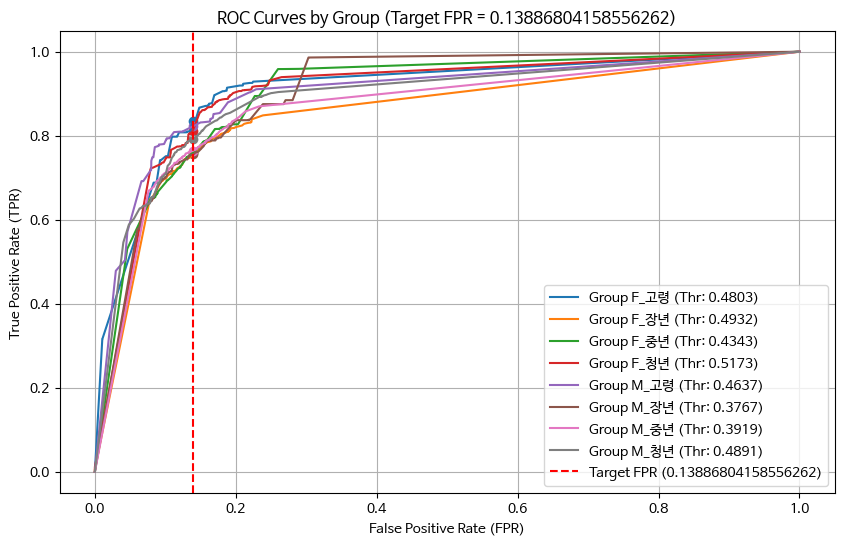

       [최종 모델 전체 성능 결과]        
F1-Score  : 0.4028
PR-AUC : 0.3176
Recall    : 0.4745
Precision : 0.3499

       [최종 - 집단별 임계값]       
Group F_고령: 0.4803
Group F_장년: 0.4932
Group F_중년: 0.4343
Group F_청년: 0.5173
Group M_고령: 0.4637
Group M_장년: 0.3767
Group M_중년: 0.3919
Group M_청년: 0.4891

       [최종 - 연령대별 공정성 세부 지표]       
         selection_rate       tpr       tnr       fpr       fnr
gen_age                                                        
F_고령           0.190572  0.555332  0.842606  0.157394  0.444668
F_장년           0.223651  0.467791  0.842499  0.157501  0.532209
F_중년           0.225831  0.512849  0.825855  0.174145  0.487151
F_청년           0.234367  0.455526  0.829129  0.170871  0.544474
M_고령           0.216733  0.570930  0.820743  0.179257  0.429070
M_장년           0.211277  0.407950  0.836892  0.163108  0.592050
M_중년           0.223458  0.455504  0.818584  0.181416  0.544496
M_청년           0.229867  0.441587  0.827801  0.172199  0.558413

       [최종 - 집단 간 최대 격차 (Max Gap)] 

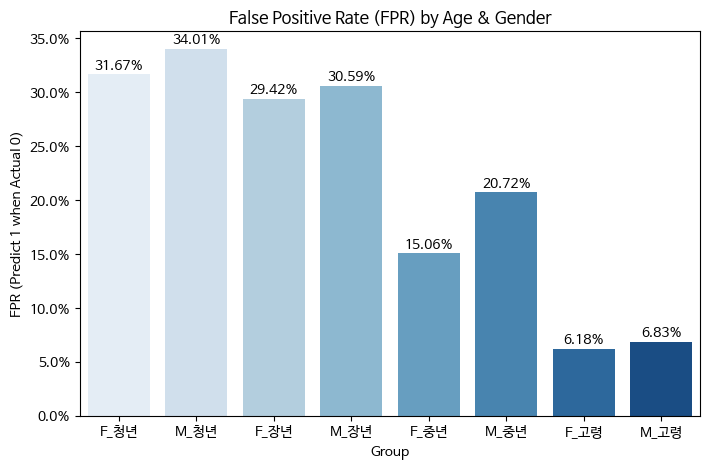

,Age_gender,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,F_청년,0.223100,0.383100,38.31%,61.46%,31.67%,35.78%
1,M_청년,0.214100,0.396100,39.61%,60.15%,34.01%,32.51%
2,F_장년,0.213200,0.359100,35.91%,59.87%,29.42%,35.54%
3,M_장년,0.196700,0.358600,35.86%,57.39%,30.59%,31.48%
4,F_중년,0.152600,0.201400,20.14%,48.32%,15.06%,36.62%
5,M_중년,0.153400,0.249000,24.90%,47.99%,20.72%,29.56%
6,F_고령,0.083400,0.085000,8.50%,34.00%,6.18%,33.37%
7,M_고령,0.095700,0.097700,9.77%,37.56%,6.83%,36.79%



 [Step 1] Fairlearn Mitigator (1차 보정) 학습 결과



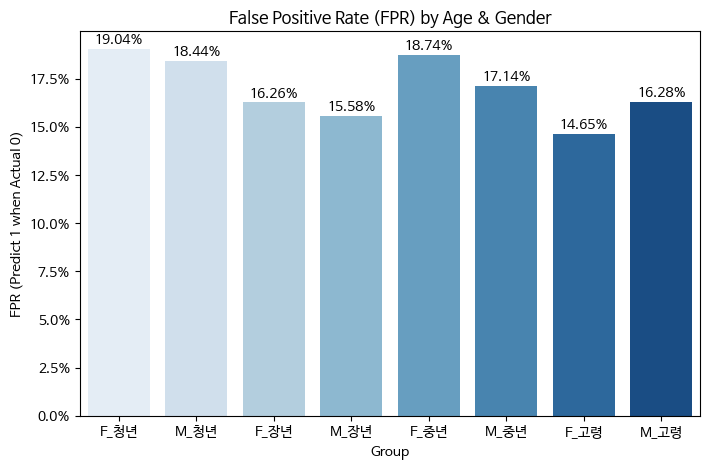

,Age_gender,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,F_청년,0.223100,0.243400,24.34%,42.80%,19.04%,39.23%
1,M_청년,0.214100,0.237800,23.78%,43.38%,18.44%,39.05%
2,F_장년,0.213200,0.225400,22.54%,45.71%,16.26%,43.23%
3,M_장년,0.196700,0.204400,20.44%,40.31%,15.58%,38.79%
4,F_중년,0.152600,0.234700,23.47%,49.72%,18.74%,32.33%
5,M_중년,0.153400,0.213700,21.37%,44.69%,17.14%,32.09%
6,F_고령,0.083400,0.176600,17.66%,50.70%,14.65%,23.94%
7,M_고령,0.095700,0.197600,19.76%,52.67%,16.28%,25.51%



 [Step 2] Post-processing (2차 임계값 튜닝) 결과



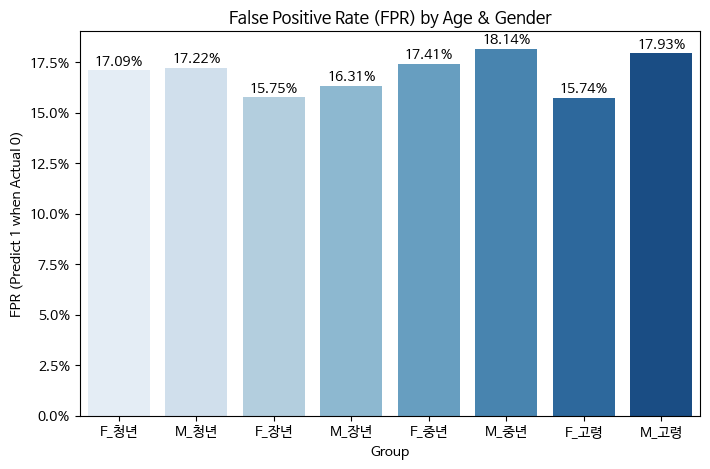

,Age_gender,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,F_청년,0.223100,0.234400,23.44%,45.55%,17.09%,43.36%
1,M_청년,0.214100,0.229900,22.99%,44.16%,17.22%,41.12%
2,F_장년,0.213200,0.223700,22.37%,46.78%,15.75%,44.59%
3,M_장년,0.196700,0.211300,21.13%,40.79%,16.31%,37.99%
4,F_중년,0.152600,0.225800,22.58%,51.28%,17.41%,34.65%
5,M_중년,0.153400,0.223500,22.35%,45.55%,18.14%,31.27%
6,F_고령,0.083400,0.190600,19.06%,55.53%,15.74%,24.30%
7,M_고령,0.095700,0.216700,21.67%,57.09%,17.93%,25.21%



       [공통 임계값]       
0.5024092

       [연령대별 공정성 세부 지표]       
         selection_rate       tpr       tnr       fpr       fnr
gen_age                                                        
F_고령           0.084969  0.340040  0.938232  0.061768  0.659960
F_장년           0.359128  0.598671  0.705776  0.294224  0.401329
F_중년           0.201364  0.483240  0.849396  0.150604  0.516760
F_청년           0.383117  0.614555  0.683331  0.316669  0.385445
M_고령           0.097686  0.375581  0.931718  0.068282  0.624419
M_장년           0.358623  0.573919  0.694108  0.305892  0.426081
M_중년           0.249039  0.479895  0.792786  0.207214  0.520105
M_청년           0.396075  0.601453  0.659866  0.340134  0.398547
       [학습 전 결과]       
F1-Score  : 0.4128
PR-AUC : 0.3990
Recall    : 0.5301
Precision : 0.3381
공통 임계값: 0.5024092197418213

집단 간 최대 격차 (Max Gap)
selection_rate    0.311106
tpr               0.274515
tnr               0.278366
fpr               0.278366
fnr               0.274515
dtype: float6

/usr/local/lib/python3.12/dist-packages/fairlearn/postprocessing/_interpolated_thresholder.py:149: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.01105409 0.01105409 0.01105409 ... 0.01105409 0.7539822  0.22536575]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  positive_probs[sensitive_feature_vector == a] = interpolated_predictions[


       [최종 모델 전체 성능 결과]        
F1-Score  : 0.3193
PR-AUC : 0.2345
Recall    : 0.2440
Precision : 0.4617

       [집단별 임계값]       
연령대: F_고령    | 추정 임계값: 0.4937
연령대: F_장년    | 추정 임계값: 0.7132
연령대: F_중년    | 추정 임계값: 0.4989
연령대: F_청년    | 추정 임계값: 0.5540
연령대: M_고령    | 추정 임계값: 0.4985
연령대: M_장년    | 추정 임계값: 0.5106
연령대: M_중년    | 추정 임계값: 0.5450
연령대: M_청년    | 추정 임계값: 0.5294

       [연령대별 공정성 세부 지표]       
         selection_rate       tpr       tnr       fpr       fnr
gen_age                                                        
F_고령           0.076246  0.278672  0.942167  0.057833  0.721328
F_장년           0.087738  0.246933  0.955395  0.044605  0.753067
F_중년           0.085592  0.273743  0.948290  0.051710  0.726257
F_청년           0.098485  0.240970  0.942424  0.057576  0.759030
M_고령           0.078994  0.283721  0.942667  0.057333  0.716279
M_장년           0.082865  0.213389  0.949103  0.050897  0.786611
M_중년           0.083822  0.212920  0.939568  0.060432  0.787080
M_청년           0.09166

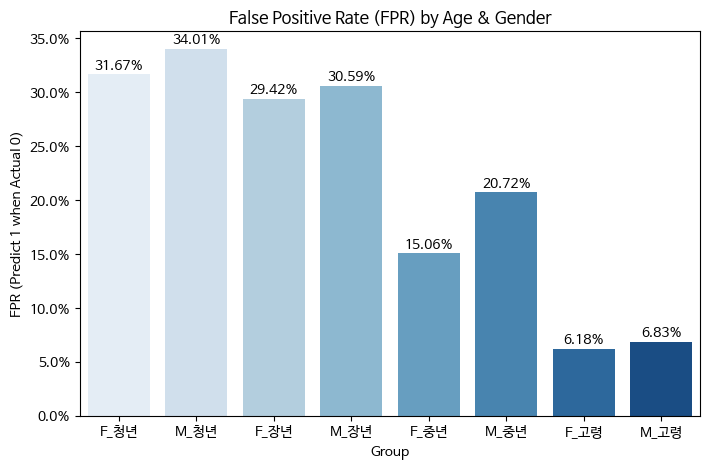

,Age_gender,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,F_청년,0.223100,0.383100,38.31%,61.46%,31.67%,35.78%
1,M_청년,0.214100,0.396100,39.61%,60.15%,34.01%,32.51%
2,F_장년,0.213200,0.359100,35.91%,59.87%,29.42%,35.54%
3,M_장년,0.196700,0.358600,35.86%,57.39%,30.59%,31.48%
4,F_중년,0.152600,0.201400,20.14%,48.32%,15.06%,36.62%
5,M_중년,0.153400,0.249000,24.90%,47.99%,20.72%,29.56%
6,F_고령,0.083400,0.085000,8.50%,34.00%,6.18%,33.37%
7,M_고령,0.095700,0.097700,9.77%,37.56%,6.83%,36.79%



 [Step 3] Base Model (보정 전) 학습 결과


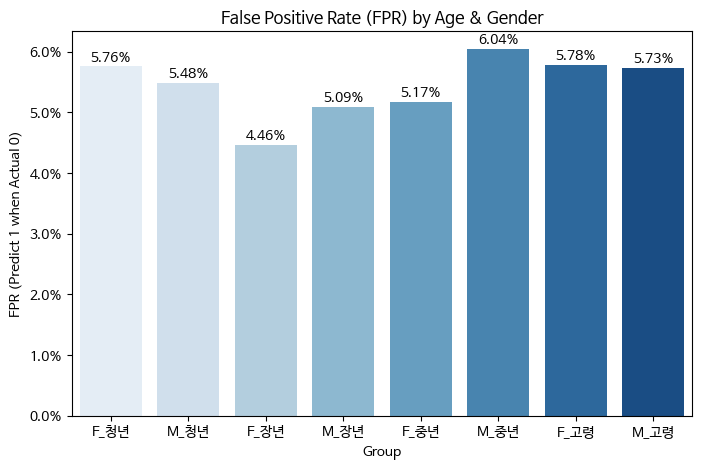

,Age_gender,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,F_청년,0.223100,0.098500,9.85%,24.10%,5.76%,54.58%
1,M_청년,0.214100,0.091700,9.17%,22.69%,5.48%,53.00%
2,F_장년,0.213200,0.087700,8.77%,24.69%,4.46%,60.00%
3,M_장년,0.196700,0.082900,8.29%,21.34%,5.09%,50.66%
4,F_중년,0.152600,0.085600,8.56%,27.37%,5.17%,48.80%
5,M_중년,0.153400,0.083800,8.38%,21.29%,6.04%,38.96%
6,F_고령,0.083400,0.076200,7.62%,27.87%,5.78%,30.47%
7,M_고령,0.095700,0.079000,7.90%,28.37%,5.73%,34.37%


In [ ]:
var_name = 'age_gender'
x_test_sensitive, y_pred_org, y_pred_mit_3, y_pred_post_3 = fairlearn_run_all(
        var_name, variable_map,
        x_train, y_train, x_val, y_val, x_test, y_test,
        best_params, fixed_params, threshold
        )

var_name = 'age_gender'
y_pred_final_3 = fairlearn_run_thr(model, threshold, var_name, x_train, y_train, x_val, y_val, x_test, y_test)

In [ ]:
y_pred_idx_2 = pd.read_pickle("Model/xgb_orth_rw_predictions.pkl")

In [ ]:
y_pred_idx_2

{'y_test': array([0, 0, 0, ..., 0, 0, 0]),
 'y_prob': array([0.04031469, 0.06064991, 0.22357097, ..., 0.5356864 , 0.47999272,
        0.45370784], dtype=float32),
 'y_pred': array([0, 0, 0, ..., 1, 0, 0])}

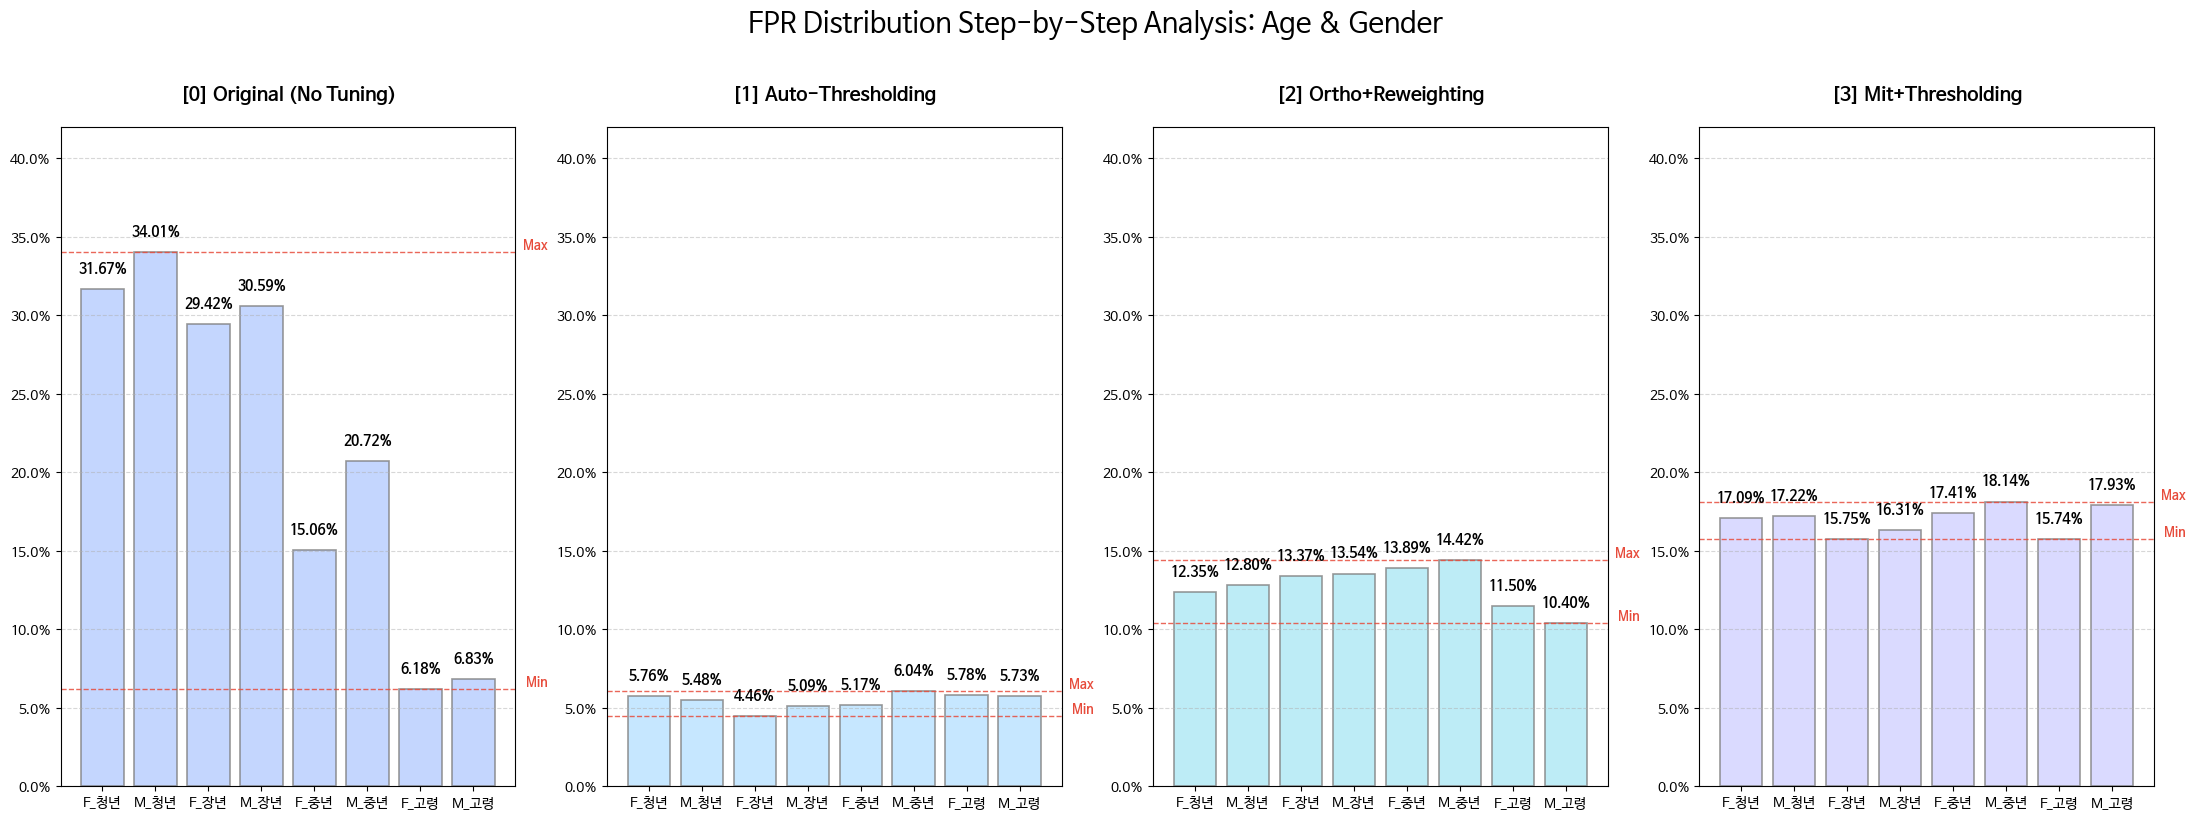

In [ ]:
y_pred_idx_1 = y_pred_final_3
y_pred_idx_2 = y_pred_idx_2['y_pred']
y_pred_idx_3 = y_pred_post_3

y_preds = [y_pred_org, y_pred_idx_1, y_pred_idx_2, y_pred_idx_3]
plot_combined_fpr(var_name, y_test, y_preds, x_test_sensitive)